In [1]:
import pandas as pd
from datapreparation.data_preparation import Data_Preparation as dp
prep = dp()
X = prep.prepare_data_general_v2
X

,mac_id,PumpTimeInSeconds,WaterLevel,hours_since_watering,soil_deficit_ratio,deficit_x_light,deficit_x_temp,deficit_x_air,et_approx
0,0,0.00,89.35,0.0,-0.007826,-0.002786,0.003209,0.018313,195.476829
1,12,0.00,86.83,0.0,0.005470,NaN,-0.003774,-0.012198,NaN
2,10,0.00,86.12,0.0,0.003130,0.000423,0.001409,-0.001377,225.217602
3,5,0.00,99.02,0.0,-0.018497,-0.011265,0.025526,0.032000,790.036223
4,6,0.00,90.73,0.0,0.001893,0.000580,-0.001250,-0.007081,205.738271
...,...,...,...,...,...,...,...,...,...
134276,11,7.21,56.42,156.0,0.374447,-0.805810,-0.670260,-0.116079,6.906311
134277,1,6.71,23.52,21.0,0.275149,NaN,-0.349439,-0.148581,NaN
134278,12,5.42,55.33,86.0,0.199829,-0.548930,-0.553526,-0.839282,0.000000
134279,0,5.71,59.51,60.0,0.193391,-0.511133,-0.187590,-0.518289,2.641856


In [2]:
y = X['PumpTimeInSeconds']
X = X.drop(columns=['PumpTimeInSeconds','WaterLevel'])
y

0         0.00
1         0.00
2         0.00
3         0.00
4         0.00
          ... 
134276    7.21
134277    6.71
134278    5.42
134279    5.71
134280    6.29
Name: PumpTimeInSeconds, Length: 134281, dtype: float64

<Figure size 900x500 with 0 Axes>

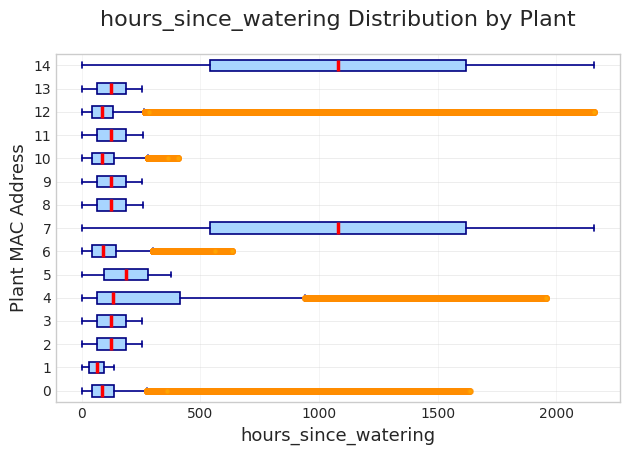

<Figure size 900x500 with 0 Axes>

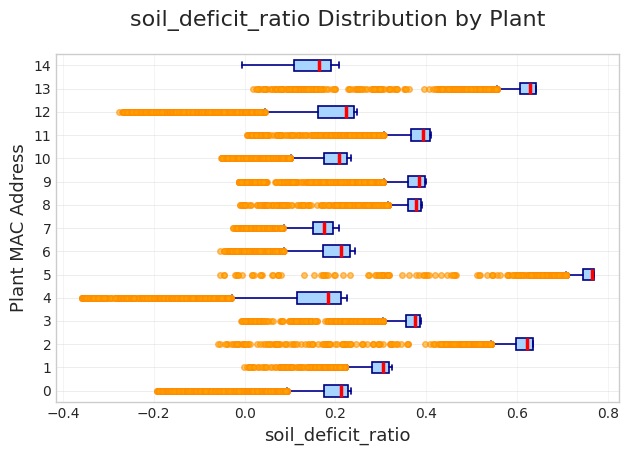

<Figure size 900x500 with 0 Axes>

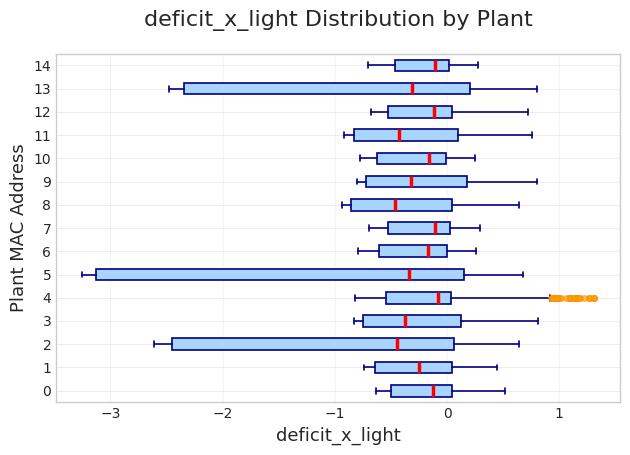

<Figure size 900x500 with 0 Axes>

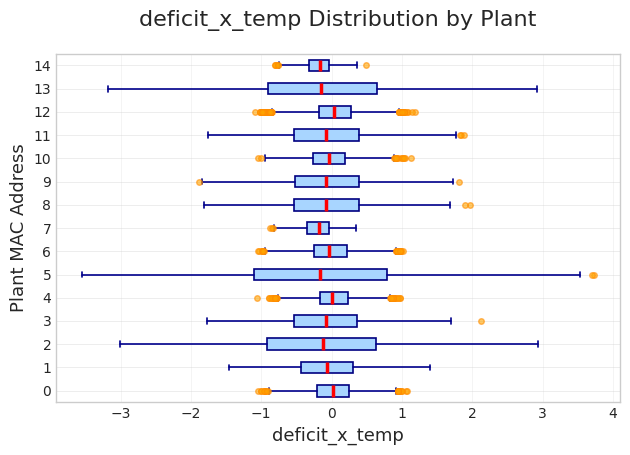

<Figure size 900x500 with 0 Axes>

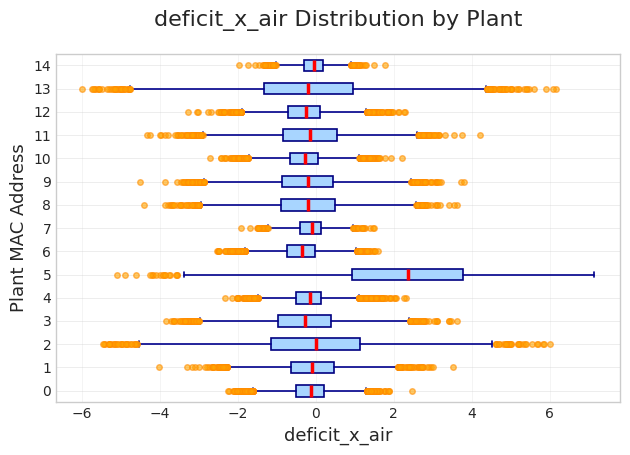

<Figure size 900x500 with 0 Axes>

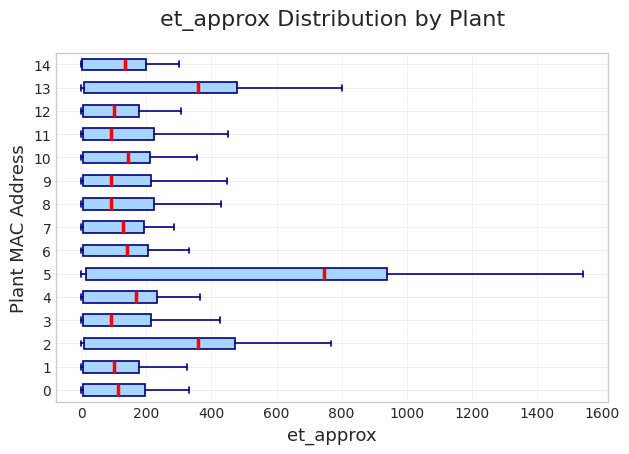

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = X.select_dtypes(include='number').columns.drop("mac_id")
plt.style.use('seaborn-v0_8-whitegrid')

for col in numeric_cols:

    plt.figure(figsize=(9, 5))

    X.boxplot(
        column=col,
        by='mac_id',
        vert=False,
        patch_artist=True,

        # Box styling
        boxprops=dict(
            facecolor='#a8d5ff',
            edgecolor='navy',
            linewidth=1.2
        ),

        # Median line
        medianprops=dict(
            color='red',
            linewidth=2.5
        ),

        # Whiskers
        whiskerprops=dict(
            color='darkblue',
            linewidth=1.2
        ),

        # Caps
        capprops=dict(
            color='darkblue',
            linewidth=1.2
        ),

        # Outliers
        flierprops=dict(
            marker='o',
            markerfacecolor='orange',
            markeredgecolor='darkorange',
            markersize=4,
            alpha=0.6
        )
    )

    plt.title(f"{col} Distribution by Plant", fontsize=16, pad=20)
    plt.suptitle("")

    plt.xlabel(col, fontsize=13)
    plt.ylabel("Plant MAC Address", fontsize=13)

    plt.xticks(rotation=0)

    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

<Figure size 700x500 with 0 Axes>

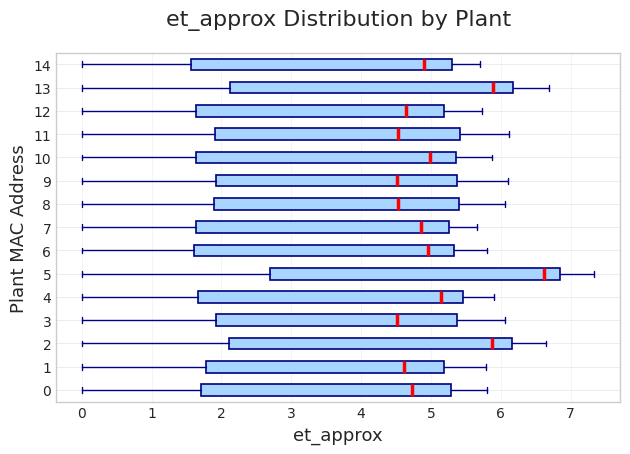

In [4]:
import numpy as np
# transform feature that are right-skewed
X["et_approx"] = X["et_approx"].apply(lambda x: np.log1p(x))

# Optional: nicer style
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure
plt.figure(figsize=(7, 5))

X.boxplot(
    column='et_approx',
    by='mac_id',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#a8d5ff', edgecolor='navy', linewidth=1.2),
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(color='darkblue'),
    capprops=dict(color='darkblue'),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.6)
)

plt.title("et_approx Distribution by Plant", fontsize=16, pad=20)
plt.suptitle("")
plt.xlabel("et_approx", fontsize=13)
plt.ylabel("Plant MAC Address", fontsize=13)


plt.xticks(rotation=0)
plt.grid(axis='x', alpha=0.3)

ax = plt.gca()
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

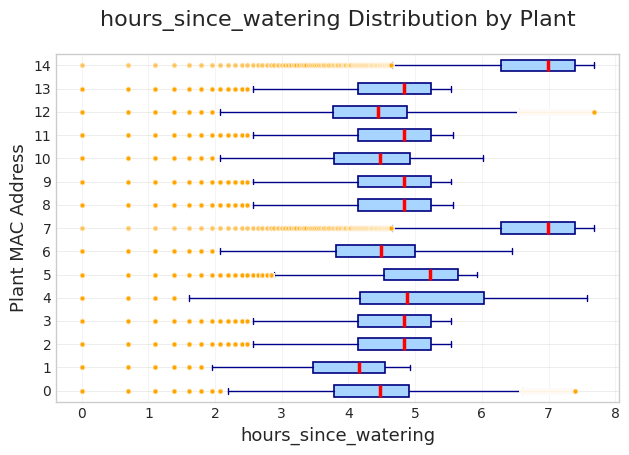

In [5]:
import numpy as np
# transform feature that are right-skewed
X["hours_since_watering"] = X["hours_since_watering"].apply(lambda x: np.log1p(x))

# Optional: nicer style
plt.style.use('seaborn-v0_8-whitegrid')

# Create the figure
plt.figure(figsize=(7, 5))

X.boxplot(
    column='hours_since_watering',
    by='mac_id',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#a8d5ff', edgecolor='navy', linewidth=1.2),
    medianprops=dict(color='red', linewidth=2.5),
    whiskerprops=dict(color='darkblue'),
    capprops=dict(color='darkblue'),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.6)
)

plt.title("hours_since_watering Distribution by Plant", fontsize=16, pad=20)
plt.suptitle("")
plt.xlabel("hours_since_watering", fontsize=13)
plt.ylabel("Plant MAC Address", fontsize=13)


plt.xticks(rotation=0)
plt.grid(axis='x', alpha=0.3)

ax = plt.gca()
plt.tight_layout()
plt.show()

## Split data

In [6]:
X = X.drop(columns=["mac_id"])
X_train, X_val, X_test, y_train, y_val, y_test = prep.train_val_test_split_64_16_20(df = X , label = y)
X_train

,hours_since_watering,soil_deficit_ratio,deficit_x_light,deficit_x_temp,deficit_x_air,et_approx
4105,5.613128,0.768786,-3.230439,NaN,-2.429364,NaN
2730,5.209486,0.091826,NaN,-0.247012,-0.604216,NaN
84024,4.430817,0.562348,-2.303659,-0.073105,1.591445,0.714663
106895,4.897840,0.182957,-0.054430,-0.064035,-0.934908,5.175905
8842,6.380123,-0.017949,0.049188,0.052231,0.068026,0.283182
...,...,...,...,...,...,...
62835,5.393628,0.341353,-0.661372,0.314045,-0.559820,2.006201
90812,1.098612,0.220000,-0.397760,0.096800,-0.358600,4.092834
74102,3.465736,0.216772,-0.281912,0.567943,0.351171,5.128716
75779,5.332719,NaN,NaN,NaN,NaN,5.392630


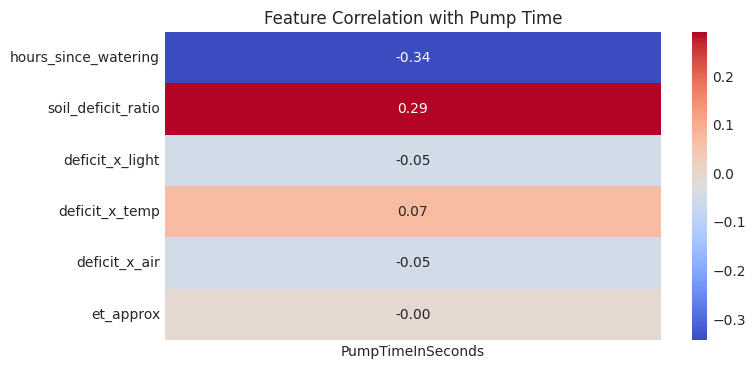

In [7]:
from sklearn.metrics import confusion_matrix, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# correlation of each feature with target
corr_series = X_train.corrwith(y_train)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_series.to_frame(name='PumpTimeInSeconds'),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation with Pump Time')
plt.show()

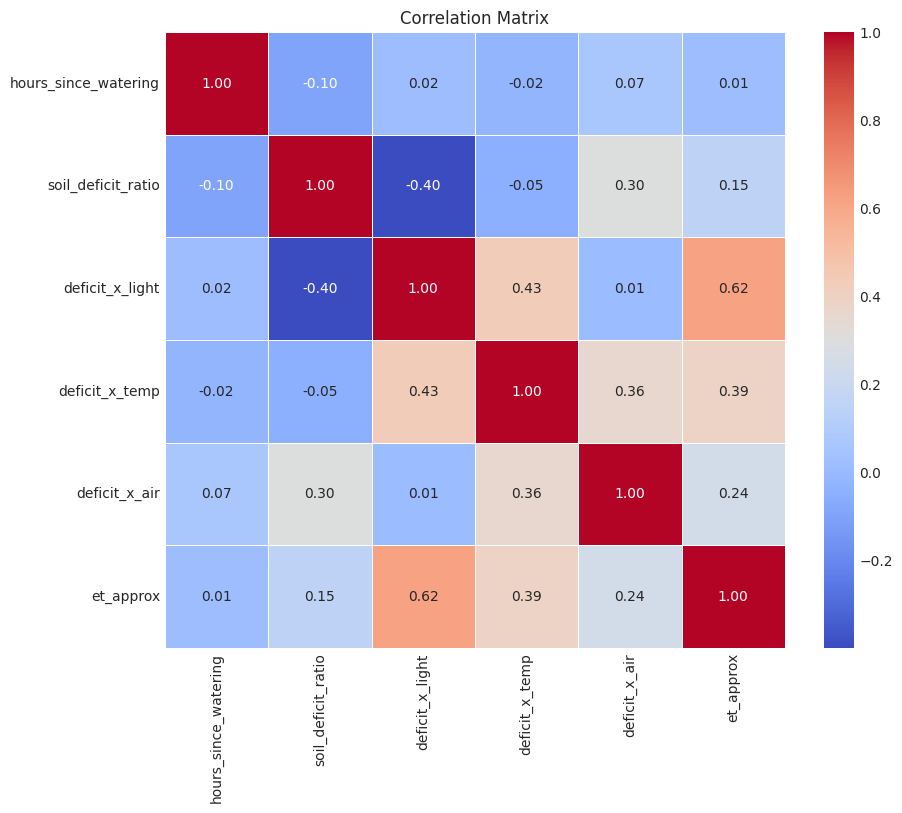

In [8]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

In [9]:
# numeric_cols = X_train.select_dtypes(include='number').columns
# train_means = X_train[numeric_cols].mean()
#
# X_train[numeric_cols] = X_train[numeric_cols].fillna(train_means)
#
# X_val[numeric_cols] = X_val[numeric_cols].fillna(train_means)
#
# X_test[numeric_cols] = X_test[numeric_cols].fillna(train_means)

In [10]:
#Interpolation
X_train_inter, X_val_inter, X_test_inter, y_train_inter, y_val_inter, y_test_inter = prep.train_val_test_split_64_16_20_func(
     func=prep.prepare_data_pump_time_v3
 )
X_train_inter

,hours_since_watering,soil_deficit_ratio,deficit_x_light,deficit_x_temp,deficit_x_air,et_approx
4105,70.0,0.230783,-0.222821,0.101544,-0.272323,4.773484
2730,47.0,0.230261,0.057220,-0.119736,-0.628612,5.233214
84024,46.0,0.375940,-0.727256,0.172932,-0.951128,2.007172
106895,118.0,0.399754,-0.879459,1.031366,0.991391,1.609964
8842,477.0,-0.093217,0.010161,0.040083,-0.041948,5.159491
...,...,...,...,...,...,...
62835,50.0,0.220826,-0.196314,0.015458,0.541024,5.066143
90812,217.0,0.398496,-0.778462,0.438346,0.175338,1.844480
74102,48.0,0.390863,-0.928495,0.234518,-0.400635,0.709396
75779,90.0,0.382741,-0.747302,0.566457,0.815239,3.749408


In [11]:
X_train_inter.loc[:, "hours_since_watering"] = np.log1p(X_train_inter["hours_since_watering"])
X_val_inter.loc[:, "hours_since_watering"] = np.log1p(X_val_inter["hours_since_watering"])
X_test_inter.loc[:, "hours_since_watering"] = np.log1p(X_test_inter["hours_since_watering"])
X_train

,hours_since_watering,soil_deficit_ratio,deficit_x_light,deficit_x_temp,deficit_x_air,et_approx
4105,5.613128,0.768786,-3.230439,NaN,-2.429364,NaN
2730,5.209486,0.091826,NaN,-0.247012,-0.604216,NaN
84024,4.430817,0.562348,-2.303659,-0.073105,1.591445,0.714663
106895,4.897840,0.182957,-0.054430,-0.064035,-0.934908,5.175905
8842,6.380123,-0.017949,0.049188,0.052231,0.068026,0.283182
...,...,...,...,...,...,...
62835,5.393628,0.341353,-0.661372,0.314045,-0.559820,2.006201
90812,1.098612,0.220000,-0.397760,0.096800,-0.358600,4.092834
74102,3.465736,0.216772,-0.281912,0.567943,0.351171,5.128716
75779,5.332719,NaN,NaN,NaN,NaN,5.392630


## Since the data is not as skewed anymore we are going to do Standard scaling since it mostly follows gaussian distribution

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train_inter)
X_val_scaled = scaler.transform(X_val_inter)
X_test_scaled = scaler.transform(X_test_inter)

X_train_scaled

,hours_since_watering,soil_deficit_ratio,deficit_x_light,deficit_x_temp,deficit_x_air,et_approx
4105,-0.266882,-0.580916,0.266232,0.221183,-0.205462,0.425666
2730,-0.597183,-0.583518,0.631892,-0.094385,-0.480951,0.640592
84024,-0.614946,0.142822,-0.392431,0.322990,-0.730325,-0.867595
106895,0.168855,0.261558,-0.591170,1.547205,0.771662,-1.053292
8842,1.342045,-2.196346,0.570445,0.133534,-0.027332,0.606126
...,...,...,...,...,...,...
62835,-0.546032,-0.630558,0.300842,0.098415,0.423431,0.562485
90812,0.679623,0.255286,-0.459293,0.701497,0.140677,-0.943654
74102,-0.579786,0.217227,-0.655197,0.410817,-0.304675,-1.474311
75779,-0.057486,0.176732,-0.418606,0.884196,0.635458,-0.053093


In [13]:
# 1. Feature Clipping (Preventing sensor spikes from hijacking the weights)
X_train_scaled = X_train_scaled.clip(lower=-3, upper=3)
X_val_scaled = X_val_scaled.clip(lower=-3, upper=3)
X_test_scaled = X_test_scaled.clip(lower=-3, upper=3)

# 2. Final Label Sync (The "Safety Dance")
# Ensuring y_train exactly matches the rows we have in X
y_train = y_train.loc[X_train_scaled.index]
y_val = y_val.loc[X_val_scaled.index]
y_test = y_test.loc[X_test_scaled.index]

In [14]:
import optuna
import xgboost as xgb
import numpy as np
from sklearn.metrics import root_mean_squared_error

# Ensure your DMatrices are fresh
dtrain = xgb.DMatrix(X_train_scaled, label=y_train_inter)
dval = xgb.DMatrix(X_val_scaled, label=y_val_inter)
dtest = xgb.DMatrix(X_test_scaled, label=y_test_inter)
def get_xgb_device():
    try:
        # tries to init CUDA, falls back if not available
        test = xgb.XGBClassifier(device="cuda", n_estimators=1)
        return "cuda"
    except Exception:
        return "cpu"
def objective(trial):
    params = {
        "verbosity": 0,
        "objective": "reg:squarederror",
        "booster": "gblinear",
        "device": get_xgb_device(),
        "updater": "coord_descent",

        # 1. LOOSEN REGULARIZATION:
        # Lower these so the model is allowed to actually use the features.
        "lambda": trial.suggest_float("lambda", 1e-3, 0.1, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 0.1, log=True),

        # 2. INCREASE LEARNING RATE:
        # 1e-7 is too slow. Let's try a more standard range.
        "eta": trial.suggest_float("learning_rate", 0.001, 0.1, log=True),

        # 3. CHANGE FEATURE SELECTION:
        # 'greedy' can sometimes be too aggressive and drop everything.
        # 'cyclic' ensures every feature gets a chance to be learned.
        "feature_selector": "cyclic",
    }

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=trial.suggest_int("n_estimators", 500, 3000),
        evals=[(dval, "validation")],
        early_stopping_rounds=50,
        verbose_eval=False
    )

    preds = model.predict(dval)
    rmse = root_mean_squared_error(y_val, preds)
    return rmse

# 1. Optimize with a focus on high-penalty ranges
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

# 2. Final Training
best_params = study.best_params
best_params.update({
    "booster": "gblinear",
    "objective": "reg:squarederror",
    "device": "cuda",
    "updater": "coord_descent"
})

final_model = xgb.train(best_params, dtrain, num_boost_round=2000)

[I 2026-05-18 08:27:49,395] A new study created in memory with name: no-name-96127b18-a2cb-46f7-93df-b1d8658f443a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-18 08:28:13,550] Trial 0 finished with value: 2.079926161239534 and parameters: {'lambda': 0.03630101324560078, 'alpha': 0.007871467411296582, 'learning_rate': 0.0013232390057867493, 'n_estimators': 1105}. Best is trial 0 with value: 2.079926161239534.
[I 2026-05-18 08:28:45,795] Trial 1 finished with value: 2.1209171381631235 and parameters: {'lambda': 0.006613467784687007, 'alpha': 0.004709691051498097, 'learning_rate': 0.0011668936175422244, 'n_estimators': 1788}. Best is trial 0 with value: 2.079926161239534.
[I 2026-05-18 08:29:31,934] Trial 2 finished with value: 2.151707913070637 and parameters: {'lambda': 0.05982920106845423, 'alpha': 0.0015717167599390103, 'learning_rate': 0.01816361226061523, 'n_estimators': 2452}. Best is trial 0 with value: 2.079926161239534.
[I 2026-05-18 08:29:48,821] Trial 3 finished with value: 2.137650805376042 and parameters: {'lambda': 0.056585496213669775, 'alpha': 0.01858113356686681, 'learning_rate': 0.004147658482628115, 'n_estimators'

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
d = xgb.DMatrix(X_val_scaled, label=y_val)
# evaluate
preds_val = final_model.predict(dval)
preds_test = final_model.predict(dtest)

print(f"\nVal  MAE: {mean_absolute_error(y_val, preds_val):.3f}")
print(f"Val  MSE: {mean_squared_error(y_val, preds_val):.3f}")
print(f"Val  R²:  {r2_score(y_val, preds_val):.4f}")
print(f"\nTest MAE: {mean_absolute_error(y_test, preds_test):.3f}")
print(f"Test MSE: {mean_squared_error(y_test, preds_test):.3f}")
print(f"Test R²:  {r2_score(y_test, preds_test):.4f}")
import os
# Delete old model before training
if os.path.exists("/models/pump_time/xgb_pump_time_regretion_model.ubj"):
    os.remove("/models/pump_time/xgb_pump_time_regretion_model.ubj")
    print("Old model deleted")

import os
# Delete old model before training
if os.path.exists("/models/pump_time/liniar_reg_model.ubj"):
    os.remove("/models/pump_time/liniar_reg_model.ubj")
    print("Old model deleted")

final_model.save_model("/workspace/models/pump_time/liniar_reg_model.ubj")
print("\nModel saved.")


Val  MAE: 1.467
Val  MSE: 4.501
Val  R²:  -0.1881

Test MAE: 1.484
Test MSE: 4.590
Test R²:  -0.1937

Model saved.
